# Setup


In [1]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
from pipeline.extract.readers import read_excel, read_parquet

In [67]:
lf_index = pl.scan_parquet("../data/processed/retrainability_index/retrainability_index.parquet")
lf_rti_subsector = pl.scan_parquet("../data/processed/routine_task_intensity/routine_task_intensity_subsector.parquet")
lf_occupations = pl.scan_parquet("../data/processed/occupations/occupations.parquet")
lf_workforce_boards = pl.scan_parquet("../data/processed/workforce_boards/workforce_boards_all_grouped.parquet")
lf_total_count_by_state = pl.scan_parquet("../data/processed/performance_records/count_by_state.parquet")

### Categorical Maps


In [3]:
# Remap numeric column values to interpretable values.
sex_map = {
    1: "Male",
    2: "Female",
    9: "Participant did not self-identify",
}

employment_status_map = {
    1: "Employed",
    2: "Employed, but Received Notice of \
    Termination of Employment or Military \
    Separation is pending",
    3: "Not in labor force",
    0: "Unemployed"
}

race_map = {
    1: "Hispanic",
    2: "Asian (not Hispanic)",
    3: "Black (not Hispanic)",
    4: "Native Hawaiian or Pacific Islander (not Hispanic)",
    5: "American Indian or Alaska Native (not Hispanic)",
    6: "White (not Hispanic)",
    7: "Multiple Race (not Hispanic)",
}

def age_map(age):
  if (age < 5):
    return "Under 5 years"
  elif (5 <= age < 17):
    return "5 to 17 years"
  elif (17 <= age < 25):
    return "17 to 24 years"
  elif (25 <= age < 35):
    return "25 to 34 years"
  elif (35 <= age < 45):
    return "35 to 44 years"
  elif (45 <= age < 55):
    return "45 to 54 years"
  elif (55 <= age < 65):
    return "55 to 64 years"
  elif (65 <= age < 85):
    return "65 to 84 years"
  elif (85 <= age < 100):
    return "85 to 99 years"
  elif (100 <= age):
    return "100 years and over"
  else:
    return "Unknown"

highest_educational_level_map = {
  1: "Attained secondary school diploma",
  2: "Attained a secondary school equivalency",
  3: "The participant with a disability receives \
  a certificate of attendance/completion as a \
  result of successfully completing an \
  Individualized Education Program (IEP)",
  4: "Completed one of more years of postsecondary education",
  5: "Attained a postsecondary technical or vocational certificate (non-degree)",
  6: "Attained an Associate's degree",
  7: "Attained a Bachelor's degree",
  8: "Attained a degree beyond a Bachelor's degree",
  0: "No Educational Level Completed",
}

low_income_status_map = {
    1: "Yes",
    0: "No"
}

received_training_map = {
  1: "Yes",
  0: "No"
}

training_service_map = {
  1: "On the Job Training (non-WIOA Youth)",
  2: "Skill Upgrading",
  3: "Entrepreneurial Training (non-WIOA Youth)",
  4: "ABE or ESL (contextualized or other) in conjunction with Training",
  5: "Customized Training",
  6: "Occupational Skills Training (non-WIOA Youth)",
  7: "ABE or ESL (contextualized or other) NOT in conjunction with training (funded by Trade Adjustment Assistance only)",
  8: "Prerequisite Training",
  9: "Registered Apprenticeship",
  10: "Youth Occupational Skills Training",
  11: "Other Non-Occupational-Skills Training",
  12: "Job Readiness Training in conjunction with other training",
  00: "No Training Service",
}

# Create Indexes

1. Index
2. Index by State
3. Index by Sector


In [68]:
columns = [
    'wages_mean_diff',
    'diff_r_cog_subsector',
    'diff_r_man_subsector',
    'diff_offshor_subsector'
]

lf_index_full = (
    lf_index
    .drop_nulls(subset=columns)
    .join(
        lf_occupations.select(["occupation_code", "occupation_title"]),
        left_on="occupational_code_pre",
        right_on="occupation_code",
        how="left"
    )
    .rename({
        "occupation_title": "occupation_title_pre"
    })
    .join(
        lf_occupations.select(["occupation_code", "occupation_title"]),
        left_on="occupational_code_post",
        right_on="occupation_code",
        how="left"
    )
    .rename({
        "occupation_title": "occupation_title_post"
    })
)

In [69]:
# Proportion of participation periods that have all columns above

lf_index_full.select(pl.len()).collect() / lf_index.select(pl.len()).collect(engine="streaming")

len
f64
0.791009


In [70]:
lf_index.select(
    pl.col("exit_date").min().alias("exit_date_min"),
    pl.col("exit_date").max().alias("exit_date_max"),
    pl.len().alias("count")
).collect(engine="streaming")

exit_date_min,exit_date_max,count
date,date,u32
2016-07-01,2024-06-30,23382371


## Index by Training Services & Programs


In [71]:
# Compute the total number of participation periods

df_index_count_total = (
    lf_total_count_by_state
    .select("count_total").sum()
    .collect(engine="streaming")
)

### Index by Received Training


In [72]:
df_index_by_received_training = (
    lf_index_full
    .group_by(
        pl.col("received_training"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("age").median(),
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rate"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rate"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rate"),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort(pl.col("rank"))
)

In [73]:
df_index_by_received_training, df_profile = df_index_by_received_training.profile(engine="streaming")

In [74]:
df_index_by_received_training.write_json("../../retrainability-index-website/src/data/index_by_received_training.json")

### Index by Training Service


In [75]:
df_index_by_training_service = (
    lf_index_full
    .group_by(
        pl.col("training_service_1"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("age").median(),
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rate"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rate"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rate"),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
        pl.col("training_service_1").replace_strict(training_service_map, default=None)
    )
    .rename({"training_service_1": "training_service"})
    .sort(pl.col("rank"))
)

In [76]:
df_index_by_training_service, df_profile = df_index_by_training_service.profile(engine="streaming")

In [77]:
df_index_by_training_service.write_json("../../retrainability-index-website/src/data/index_by_training_service.json")

## Index by Participant Characteristics


In [33]:
# Compute the total number of participation periods

df_index_count_total = (
    lf_total_count_by_state
    .select("count_total").sum()
    .collect(engine="streaming")
)

### Index by Age


In [34]:
df_index_by_age = (
    lf_index_full
    .group_by(
        pl.col("age"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [35]:
df_index_by_age, df_profile = df_index_by_age.profile(engine="streaming")

In [36]:
df_index_by_age.write_json("../../retrainability-index-website/src/data/index_by_age.json")

### Index by Race/Ethnicity


In [37]:
df_index_by_race = (
    lf_index_full
    .group_by(
        pl.col("race"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("race").replace_strict(race_map, default=None),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [38]:
df_index_by_race, df_profile = df_index_by_race.profile(engine="streaming")

In [39]:
df_index_by_race.write_json("../../retrainability-index-website/src/data/index_by_race.json")

### Index by Education Level


In [52]:
df_index_by_education_level = (
    lf_index_full
    .group_by(
        pl.col("highest_educational_level"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [53]:
df_index_by_education_level, df_profile = df_index_by_education_level.profile(engine="streaming")

In [54]:
df_index_by_education_level.write_json("../../retrainability-index-website/src/data/index_by_education_level.json")

### Index by Sex


In [57]:
df_index_by_sex = (
    lf_index_full
    .group_by(
        pl.col("sex"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("sex").replace_strict(sex_map, default=None),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [58]:
df_index_by_sex, df_profile = df_index_by_sex.profile(engine="streaming")

In [59]:
df_index_by_sex.write_json("../../retrainability-index-website/src/data/index_by_sex.json")

### Index by Low Income Status


In [61]:
df_index_by_low_income_status = (
    lf_index_full
    .group_by(
        pl.col("low_income_status"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("low_income_status").replace_strict(low_income_status_map, default=None),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [62]:
df_index_by_low_income_status, df_profile = df_index_by_low_income_status.profile(engine="streaming")

In [63]:
df_index_by_low_income_status.write_json("../../retrainability-index-website/src/data/index_by_low_income_status.json")

### Index by Employment Status


In [64]:
df_index_by_employment_status = (
    lf_index_full
    .group_by(
        pl.col("employment_status"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [65]:
df_index_by_employment_status, df_profile = df_index_by_employment_status.profile(engine="streaming")

In [66]:
df_index_by_employment_status.write_json("../../retrainability-index-website/src/data/index_by_employment_status.json")

## Index by Geographic and Economic Factors


In [7]:
# Compute the total number of participation periods by state

df_index_by_state_count_total = (
    lf_total_count_by_state
    .group_by(
        pl.col("state")
    )
    .agg(
        pl.col("count_total").sum()
    )
)

### Index by State (All)


In [8]:
df_index_by_state = (
    lf_index_full
    .group_by(
        pl.col("state")
    )
    .agg(      
        pl.len().alias("count"),

        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),
        

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("age").median(),
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .join(
        df_index_by_state_count_total,
        on="state",
        how="inner"
    )
    .with_columns(
        (pl.col("count") / pl.col("count_total")).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rate"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rate"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rate"),
    )
    .sort("index", descending=True)
    .with_columns(
        pl.col("index").rank("ordinal", descending=True).alias("rank")
    )    
)


In [9]:
df_index_by_state, df_profile = df_index_by_state.profile(engine="streaming")

In [10]:
df_index_by_state.write_json("../../retrainability-index-website/src/data/index_by_state.json")

### Index by State (Recieved Training)


In [11]:
df_index_by_state = (
    lf_index_full
    .filter(
        pl.col("received_training")     
    )
    .group_by(
        pl.col("state"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("age").median(),
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .join(
        df_index_by_state_count_total,
        on="state",
        how="inner"
    )
    .with_columns(
        (pl.col("count") / pl.col("count_total")).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rate"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rate"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rate"),
    )
    .sort("index", descending=True)
    .with_columns(
        pl.col("index").rank("ordinal", descending=True).alias("rank")
    )
)

In [12]:
df_index_by_state, df_profile = df_index_by_state.profile(engine="streaming")

In [13]:
df_index_by_state.write_json("../../retrainability-index-website/src/data/index_by_state_received_training.json")

### By Rural vs Urban


In [78]:
# Compute the total number of participation periods

df_index_count_total = (
    lf_total_count_by_state
    .select("count_total").sum()
    .collect(engine="streaming")
)

In [79]:
df_index_by_rural_urban = (
    lf_index_full
    .with_columns(
        (pl.col("workforce_board_rucc") < 4).alias("is_urban")
    )
    .group_by(
        pl.col("is_urban"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("index").rank("ordinal", descending=True).alias("rank")
    )
    .sort("index", descending=True)
)

In [80]:
df_index_by_rural_urban, df_profile = df_index_by_rural_urban.profile(engine="streaming")

In [81]:
df_index_by_rural_urban.write_json("../../retrainability-index-website/src/data/index_by_rural_urban.json")

### By Median County Income


In [82]:
df_index_by_county_income = (
    lf_index_full
    .with_columns(
        pl.when(pl.col("workforce_board_median_income") < pl.col("workforce_board_median_income").quantile(0.10))
        .then(pl.col("workforce_board_median_income").quantile(0.10))
        .when(pl.col("workforce_board_median_income") < pl.col("workforce_board_median_income").quantile(0.90))
        .then(pl.col("workforce_board_median_income").quantile(0.90))
        .otherwise(pl.col("workforce_board_median_income").quantile(1))
    )
    .group_by(
        pl.col("workforce_board_median_income"),
    )
    .agg(
        pl.len().alias("count"),
        
        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Workforce Board
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),

        # Demographics
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
    )
    .with_columns(
        (pl.col("count") / df_index_count_total.item()).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rates"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rates"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rates"),
        pl.col("index").rank("ordinal", descending=True).alias("rank"),
    )
    .sort("index", descending=True)
)

In [83]:
df_index_by_county_income, df_profile = df_index_by_county_income.profile(engine="streaming")

In [84]:
df_index_by_county_income.write_json("../../retrainability-index-website/src/data/index_by_county_income.json")

### Index by Workforce Board


In [25]:
# Compute the total number of participation periods (within the sample) by state

df_index_count_total = (
    lf_index_full
    .group_by(
        pl.col("workforce_board_jurisdictions")
    )
    .agg(
        pl.len().alias("count_total")
    )
)

In [26]:
df_index = (
    lf_index_full
    .group_by(
        pl.col("state"),
        pl.col("workforce_board_jurisdictions"),
    )
    .agg(
        pl.len().alias("count"),

        # Key Outcomes
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("wages_mean_diff").median(),
        pl.col("diff_r_cog_subsector").mean(),
        pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") > 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") < 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") < 0).sum().alias("r_man_subsector_decreased_count"),

        # Program Information
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),

        # Training Details
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),

        # Demographics
        pl.col("age").median(),
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        
        # Industry Subsectors
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),

        # Occupations
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),

        # Workforce Board Demographics
        pl.col("workforce_board_median_age").mean(),    
        pl.col("workforce_board_median_income").mean(),
        pl.col("workforce_board_population_per_sqkm").mean()
    )
    .join(
        df_index_count_total,
        on="workforce_board_jurisdictions",
        how="inner"
    )
    .with_columns(
        (pl.col("count") / pl.col("count_total")).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rate"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rate"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rate"),
        pl.col("index").rank("ordinal", descending=True).alias("rank")
    )
    .sort("index", descending=True)
)

In [27]:
df_index, df_profile = df_index.profile(engine="streaming")

In [28]:
df_index.write_json("../../retrainability-index-website/src/data/index_by_workforce_board.json")

### Index by Workforce Board (Received Training)


In [29]:
# Compute the total number of participants / participation spells by state

df_index_count_total = (
    lf_index_full
    .group_by(
        pl.col("workforce_board_jurisdictions")
    )
    .agg(
        pl.len().alias("count_total")
    )
    .collect()
)

In [31]:
df_index = (
    lf_index_full
    .filter(
        pl.col("received_training")     
    )
    .group_by(
        pl.col("workforce_board_jurisdictions"),
    )
    .agg(
        (pl.col("index") > 0.5).mean().alias("index"),
        pl.col("is_adult").sum().alias("adult_count"),
        pl.col("is_dislocated_worker").sum().alias("dislocated_worker_count"),
        pl.col("is_youth").sum().alias("youth_count"),
        pl.col("is_wagner_peyser").sum().alias("wagner_peyser_count"),
        pl.col("received_training").sum().alias("received_training_count"),
        pl.col("wages_mean_diff").median(),
        -pl.col("diff_r_cog_subsector").mean(),
        -pl.col("diff_r_man_subsector").mean(),
        (pl.col("wages_mean_diff") >= 0).sum().alias("wages_mean_increase_count"),
        (pl.col("diff_r_cog_subsector") <= 0).sum().alias("r_cog_subsector_decreased_count"),
        (pl.col("diff_r_man_subsector") <= 0).sum().alias("r_man_subsector_decreased_count"),
        pl.len().alias("count"),
        pl.col("sex").replace_strict(sex_map, default=None).value_counts(sort=True, normalize=True).alias("sexes"),
        pl.col("employment_status").replace_strict(employment_status_map, default=None).value_counts(sort=True, normalize=True).alias("employment_statuses"),
        pl.col("race").replace_strict(race_map, default=None).value_counts(sort=True, normalize=True).alias("races"),
        pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None).value_counts(sort=True, normalize=True).alias("highest_educational_levels"),
        pl.col("occupation_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_pre"),
        pl.col("occupation_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_occupation_titles_post"),
        pl.col("subsector_title_pre").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_pre"),
        pl.col("subsector_title_post").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_subsector_titles_post"),
        pl.col("workforce_board_code").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_codes"),
        pl.col("workforce_board_jurisdictions").value_counts(sort=True, normalize=True).slice(0, 11).alias("top_workforce_board_jurisdictions"),
        pl.col("training_service_1").replace_strict(training_service_map, default=None).value_counts(sort=True, normalize=True).alias("training_services"),
        pl.col("workforce_board_median_age").mean(),    
        pl.col("workforce_board_median_income").mean(),
        pl.col("workforce_board_population_per_sqkm").mean()
    )
    .collect()
)

df_index = df_index.join(
    df_index_count_total,
    on="workforce_board_jurisdictions",
    how="inner"
)

df_index = (
        df_index.with_columns(
        (pl.col("count") / pl.col("count_total")).alias("coverage"),
        (pl.col("adult_count") / pl.col("count")).alias("adult_coverage"),
        (pl.col("dislocated_worker_count") / pl.col("count")).alias("dislocated_worker_coverage"),
        (pl.col("youth_count") / pl.col("count")).alias("youth_coverage"),
        (pl.col("wagner_peyser_count") / pl.col("count")).alias("wagner_peyser_coverage"),
        (pl.col("received_training_count") / pl.col("count")).alias("received_training_coverage"),
        (pl.col("wages_mean_increase_count") / pl.col("count")).alias("wages_mean_increase_rate"),
        (pl.col("r_cog_subsector_decreased_count") / pl.col("count")).alias("r_cog_subsector_decreased_rate"),
        (pl.col("r_man_subsector_decreased_count") / pl.col("count")).alias("r_man_subsector_decreased_rate"),
    )
)

In [32]:
df_index.write_json("../../retrainability-index-website/src/data/index_by_workforce_board_received_training.json")

## Index by Sector


In [13]:
df_rti_subsector = lf_rti_subsector.collect()

In [14]:
# Aggregate by subsector prior to participation
by = "subsector_code_pre"

df_index_count_total = (
    lf_index
    .group_by(
        pl.col(by)
    )
    .agg(
        pl.len().alias("count_total")
    )
    .collect()
)

In [15]:
(
    lf_index_full
    .join(
        lf_rti_subsector.select(
            pl.col("subsector_code"),
            pl.col("subsector_title")
        ),
        left_on="subsector_code_post",
        right_on="subsector_code",
        how="left"
    ).head(10).collect()
)

unique_id,sex,race,age,highest_educational_level,low_income_status,employment_status,state,is_adult,is_dislocated_worker,is_youth,is_wagner_peyser,is_reportable_individual,received_training,entry_date,exit_date,entry_year,entry_quarter,exit_year,exit_quarter,inflation_ratio_exit,inflation_ratio_entry,industry_code_pre,industry_code_post,subsector_code_pre,subsector_code_post,funding_stream,wages_mean_diff,diff_r_cog_subsector,diff_r_man_subsector,diff_offshor_subsector,subsector_title
str,i64,i64,i64,i64,i64,i64,str,bool,bool,bool,bool,bool,bool,date,date,i32,i8,i32,i8,f64,f64,str,str,str,str,str,i64,f64,f64,f64,str
"""9U4bSSe5A94F""",1,7,27,1,0,2,"""AK""",false,true,false,false,false,true,2021-02-22,2024-06-28,2021,1,2024,2,0.695134,0.804724,"""238210""","""238210""","""238000""","""238000""","""Dislocated Worker""",5505,0.0,0.0,0.0,"""Specialty trade contractors"""
"""L4ceddfA9Sf0""",2,6,45,6,1,1,"""AK""",false,true,false,true,false,true,2021-12-29,2024-03-01,2021,4,2024,1,0.695134,0.804724,"""722511""","""621330""","""722000""","""621000""","""Dislocated Worker""",10959,0.678545,-0.655802,-0.234972,"""Ambulatory healthcare services"""
"""LFUF94FDAAL0""",2,6,28,4,0,1,"""AK""",false,true,false,true,false,true,2021-12-06,2024-02-02,2021,4,2024,1,0.695134,0.804724,"""621111""","""622110""","""621000""","""622000""","""Dislocated Worker""",8209,-0.054319,-0.040102,-0.005353,"""Hospitals; state, local, and p…"
"""S45aUfL00Lea""",2,6,26,4,1,1,"""AK""",false,true,false,true,false,true,2021-11-16,2024-03-30,2021,4,2024,1,0.695134,0.804724,"""622110""","""622110""","""622000""","""622000""","""Dislocated Worker""",10487,0.0,0.0,0.0,"""Hospitals; state, local, and p…"
"""e0eccFfc5FS9""",2,7,26,4,0,1,"""AK""",true,false,false,true,false,true,2021-12-06,2024-05-04,2021,4,2024,2,0.695134,0.804724,"""621210""","""621210""","""621000""","""621000""","""Adult""",999,0.0,0.0,0.0,"""Ambulatory healthcare services"""
"""449S5abUbbdc""",2,6,28,4,0,1,"""AL""",true,false,false,true,false,true,2020-11-05,2024-05-30,2020,4,2024,2,0.695134,0.84253,"""622110""","""622110""","""622000""","""622000""","""Adult""",20752,0.0,0.0,0.0,"""Hospitals; state, local, and p…"
"""5a44cAc0U0Ae""",1,6,26,0,0,0,"""AL""",false,true,false,true,false,true,2020-01-06,2024-01-18,2020,1,2024,1,0.695134,0.84253,"""326211""","""622110""","""326000""","""622000""","""Dislocated Worker""",6344,-0.324185,-1.772949,-0.516987,"""Hospitals; state, local, and p…"
"""0UfLcbbU9a9c""",1,2,25,4,1,0,"""AK""",true,false,false,false,false,true,2021-02-23,2022-11-27,2021,1,2022,4,0.745096,0.804724,"""622110""","""445000""","""622000""","""445000""","""Adult""",2213,0.458211,0.939799,0.424056,"""Food and beverage retailers"""
"""4SUDaU49c4UA""",2,6,29,7,0,1,"""AK""",true,false,false,false,false,true,2021-08-11,2022-12-16,2021,3,2022,4,0.745096,0.804724,"""813900""","""622110""","""813000""","""622000""","""Adult""",9179,0.637418,0.256258,-0.680382,"""Hospitals; state, local, and p…"


In [16]:
df_index = (
    lf_index_full
    .join(
        lf_rti_subsector.select(
            pl.col("subsector_code"),
            pl.col("subsector_title").alias("subsector_title_post")
        ),
        left_on="subsector_code_post",
        right_on="subsector_code",
        how="left"
    )
    .group_by(
        pl.col(by)
    )
    .agg(
        pl.col("wages_mean_diff").mean(),
        -pl.col("diff_r_cog_subsector").mean(),
        -pl.col("diff_r_man_subsector").mean(),
        pl.len().alias("count"),
        pl.col("subsector_title_post")
        .value_counts(sort=True, normalize=True)
        .slice(0, 11)
        .alias("top_subsector_titles_post"),
    )
    .collect()
)

# Compute percentiles for the metric columns
df_index = (
    df_index
    .with_columns([
        pl.col(c).map_elements(
            lambda x, col=df_index[c].to_numpy(): stats.percentileofscore(col, x, "weak"),
            return_dtype=pl.Float64
        ).alias(f"{c}_percentile")
        for c in ["wages_mean_diff", "diff_r_cog_subsector", "diff_r_man_subsector"]
    ])
    .with_columns(
        (0.5 * pl.col("wages_mean_diff_percentile") 
        + 0.25 * pl.col("diff_r_cog_subsector_percentile") 
        + 0.25 *  pl.col("diff_r_man_subsector_percentile"))
        .alias("index"),
    )
)

df_index = df_index.join(
    df_index_count_total,
    on=by,
    how="inner"
)

df_index = df_index.with_columns(
    (pl.col("count") / pl.col("count_total")).alias("coverage")
)

# Add percent of total count (percent of all rows)
df_index = df_index.with_columns(
    (pl.col("count") / pl.col("count").sum()).alias("percent_of_total") * pl.lit(100)
)

In [17]:
print("shape before: ", df_index.shape)

# Join with subsector metadata
df_index = df_index.join(
    df_rti_subsector,
    left_on=by,
    right_on="subsector_code",
    how="inner"
)

print("shape after: ", df_index.shape)

shape before:  (89, 13)
shape after:  (86, 20)


In [18]:
(
    df_index.filter(
        pl.col("subsector_code_pre") == "722000"
    )
    .explode("top_occupation_titles")
    .unnest("top_occupation_titles")
    .sort("2023_percent_of_subsector", descending=True)
)

subsector_code_pre,wages_mean_diff,diff_r_cog_subsector,diff_r_man_subsector,count,top_subsector_titles_post,wages_mean_diff_percentile,diff_r_cog_subsector_percentile,diff_r_man_subsector_percentile,index,count_total,coverage,percent_of_total,sector_code,sector_title,subsector_title,r_cog_subsector,r_man_subsector,offshor_subsector,occupation_title,2023_percent_of_subsector
str,f64,f64,f64,u32,list[struct[2]],f64,f64,f64,f64,u32,f64,f64,str,str,str,f64,f64,f64,str,f64
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Waiters and Waitresses""",0.277337
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Cooks, Restaurant""",0.170536
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Hosts and Hostesses, Restauran…",0.058592
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Dishwashers""",0.049998
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Bartenders""",0.048096
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""First-Line Supervisors of Food…",0.048064
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Dining Room and Cafeteria Atte…",0.047999
"""722000""",365.370945,-0.23462,0.132361,1655664,"[{""Food services and drinking places"",0.522892}, {""Administrative and support services"",0.125668}, … {""Educational services; state, local, and private"",0.011414}]",97.752809,7.865169,57.303371,65.168539,1737438,0.952934,7.706248,"""720000""","""Accommodation and food service…","""Food services and drinking pla…",-0.496246,0.221046,-0.103748,"""Food Preparation Workers""",0.036181
"""722000""",365.370945,-0.

In [19]:
df_index.write_json("index_by_subsector.json")

# Playground


In [2]:
lf_index = pl.scan_parquet("retrainability_index.parquet")

In [13]:
lf_index.group_by(
    pl.col("subsector_code_pre")
).agg(
    pl.len().alias("spells")
).sort(by="spells").collect()

subsector_code_pre,spells
str,u32
"""550000""",3
"""927000""",10
"""540000""",14
"""482000""",159
"""560000""",738
…,…
"""621000""",862681
"""541000""",1140206
"""722000""",1737438


In [ ]:
23_867_118

In [ ]:
df_index = lf_index.collect()

In [138]:
null_counts = df_index.select(pl.all().null_count() / pl.all().len() * 100)
null_counts

unique_id,sex,race,age,highest_educational_level,low_income_status,employment_status,occupational_code_pre,industry_code_q1_pre,industry_code_q2_pre,industry_code_q3_pre,wages_3q_pre,wages_2q_pre,wages_1q_pre,occupational_code_post,industry_code_q1_post,industry_code_q2_post,industry_code_q3_post,industry_code_q4_post,wages_1q_post,wages_2q_post,wages_3q_post,wages_4q_post,workforce_board_code_1,workforce_board_code_2,workforce_board_code_3,state,is_adult,is_dislocated_worker,is_youth,is_wagner_peyser,is_reportable_individual,received_training,entry_date,exit_date,entry_year,entry_quarter,…,funding_stream,wages_mean_post,wages_mean_pre,wages_mean_diff,r_cog_pre,r_man_pre,offshor_pre,r_cog_post,r_man_post,offshor_post,r_cog_industry_pre,r_man_industry_pre,offshor_industry_pre,r_cog_industry_post,r_man_industry_post,offshor_industry_post,subsector_title_pre,r_cog_subsector_pre,r_man_subsector_pre,offshor_subsector_pre,subsector_title_post,r_cog_subsector_post,r_man_subsector_post,offshor_subsector_post,program_year,workforce_board_population_per_sqkm,workforce_board_median_age,workforce_board_median_income,diff_r_cog,diff_r_man,diff_offshor,diff_r_cog_industry,diff_r_man_industry,diff_offshor_industry,diff_r_cog_subsector,diff_r_man_subsector,diff_offshor_subsector
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.499948,12.10146,10.125463,11.661186,0.560082,0.378694,0.445301,95.760216,15.222755,25.068806,38.123285,52.587814,0.0,11.726117,26.059946,41.583059,0.035607,50.266636,96.489957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,67.974363,67.974363,67.974363,96.95369,96.95369,96.95369,80.951344,80.951344,80.951344,79.174748,79.174748,79.174748,15.464047,6.098905,6.098905,6.098905,15.976373,6.430681,6.430681,6.430681,21.278512,22.358042,22.358042,22.358042,98.593721,98.593721,98.593721,90.430011,90.430011,90.430011,10.001047,10.001047,10.001047


In [4]:
columns = [
    'unique_id',
    'sex',
    'race',
    'age',
    'highest_educational_level',
    'low_income_status',
    'employment_status',
    'state',
    'is_adult',
    'is_dislocated_worker',
    'is_youth',
    'is_wagner_peyser',
    'is_reportable_individual',
    'received_training',
    'entry_date',
    'exit_date',
    'entry_year',
    'entry_quarter',
    'exit_year',
    'exit_quarter',
    'inflation_ratio_exit',
    'inflation_ratio_entry',
    'industry_code_pre',
    'industry_code_post',
    'subsector_code_pre',
    'subsector_code_post',
    'workforce_board_code',
    'funding_stream',
    'wages_mean_diff',
    'workforce_board_population_per_sqkm',
    'workforce_board_median_age',
    'workforce_board_median_income',
    'diff_r_cog_subsector',
    'diff_r_man_subsector',
    'diff_offshor_subsector'
]

lf_complete = lf_index.select(pl.col(columns)).drop_nulls()

<Axes: ylabel='Count'>

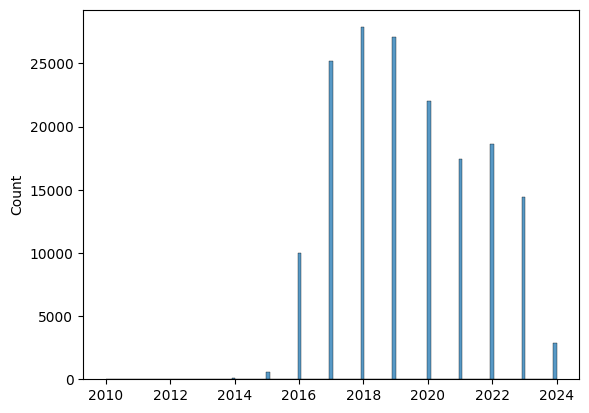

In [141]:
sns.histplot(df_complete["entry_year"])

In [13]:
df_complete = lf_complete.collect()

In [26]:
df_complete = df_complete.to_pandas()

In [27]:
p90 = int(np.percentile(df_complete["wages_mean_diff"], 90))
p10 = int(np.percentile(df_complete["wages_mean_diff"], 10))

p10, p90

(-7257, 5231)

In [32]:
mask = (df_complete["wages_mean_diff"] < p90) & (df_complete["wages_mean_diff"] > p10)

x = stats.zscore(df_complete["wages_mean_diff"])

(-20.0, 20.0)

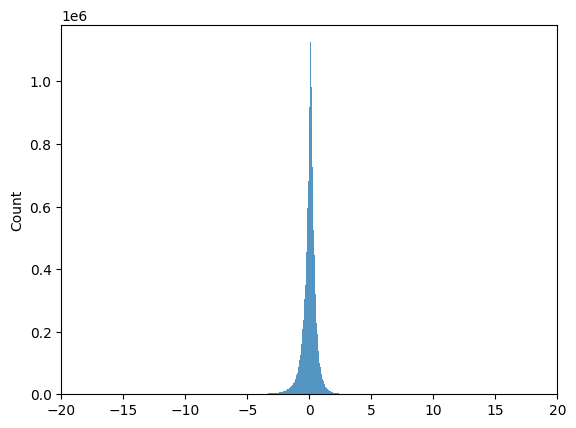

In [34]:
ax = sns.histplot(x)

ax.set_xlim(-20, 20)

In [5]:
df_by_state = lf_complete.filter(
    pl.col("received_training")
).group_by(
    pl.col("state")
).agg(
    pl.col("wages_mean_diff").mean(),
    pl.col("diff_r_cog_subsector").mean(),
    pl.col("diff_r_man_subsector").mean(),
    pl.len()
).collect()

In [6]:
df_percentiles = df_by_state.with_columns([
    pl.col(c).map_elements(
        lambda x, col=df_by_state[c].to_numpy(): stats.percentileofscore(col, x),
        return_dtype=pl.Float64
    ).alias(f"{c}_percentile")
    for c in ["wages_mean_diff", "diff_r_cog_subsector", "diff_r_man_subsector"]
])

In [7]:
df_percentiles = df_percentiles.with_columns(
    (0.5 * pl.col("wages_mean_diff_percentile") + 0.25 * (100 - pl.col("diff_r_cog_subsector_percentile")) + 0.25 *  (100 - pl.col("diff_r_man_subsector_percentile")))
    .alias("index")
)

In [10]:
df_percentiles.sort("index", descending=True)

state,wages_mean_diff,diff_r_cog_subsector,diff_r_man_subsector,len,wages_mean_diff_percentile,diff_r_cog_subsector_percentile,diff_r_man_subsector_percentile,index
str,f64,f64,f64,u32,f64,f64,f64,f64
"""AK""",6656.138889,-0.037088,-0.179519,36,100.0,21.153846,5.769231,93.269231
"""MO""",5463.794118,-0.021176,-0.036418,204,98.076923,30.769231,25.0,85.096154
"""WY""",4618.526316,-0.075717,0.003612,19,96.153846,13.461538,42.307692,84.134615
"""IA""",2049.625,-0.080703,-0.242364,24,50.0,7.692308,1.923077,72.596154
"""IL""",3215.431481,-0.024076,0.017827,540,78.846154,26.923077,50.0,70.192308
…,…,…,…,…,…,…,…,…
"""ID""",1784.567568,0.119379,0.086996,37,36.538462,96.153846,84.615385,23.076923
"""PR""",1158.588235,0.119516,0.018516,17,21.153846,98.076923,51.923077,23.076923
"""NH""",1574.5,0.038447,0.235359,18,30.769231,76.923077,96.153846,22.115385


In [11]:
df_percentiles.write_json("index.json")

In [48]:
df_by_state = df_by_state["wages_mean_diff"].to_pandas()

In [50]:
wages = df_by_state.to_numpy()

In [52]:
df_by_state.apply(lambda x: stats.percentileofscore(wages, x))

0      44.230769
1      98.076923
2      40.384615
3      51.923077
4      69.230769
5      92.307692
6       1.923077
7      25.000000
8      34.615385
9      86.538462
10     73.076923
11     55.769231
12     88.461538
13     94.230769
14     53.846154
15     38.461538
16     19.230769
17     15.384615
18     23.076923
19     17.307692
20     82.692308
21     30.769231
22     76.923077
23     59.615385
24     78.846154
25     84.615385
26     67.307692
27      5.769231
28     80.769231
29     50.000000
30      3.846154
31     13.461538
32     61.538462
33     63.461538
34     90.384615
35    100.000000
36     11.538462
37      9.615385
38     96.153846
39     75.000000
40     65.384615
41     48.076923
42     42.307692
43     21.153846
44     71.153846
45     36.538462
46     57.692308
47     26.923077
48     46.153846
49     32.692308
50      7.692308
51     28.846154
Name: wages_mean_diff, dtype: float64

In [43]:
stats.percentileofscore(df_by_state["wages_mean_diff"], 10000)

np.float64(100.0)

In [ ]:
lf_complete.group_by(
    pl.col("received_training")
).agg(
    pl.col("wages_mean_diff").mean(),
    pl.col("diff_r_cog_subsector").mean(),
    pl.col("diff_r_man_subsector").mean()
).collect()

In [10]:
0.017937 - (-0.000151), 0.020673 - (-0.007592)

(0.018088, 0.028265)

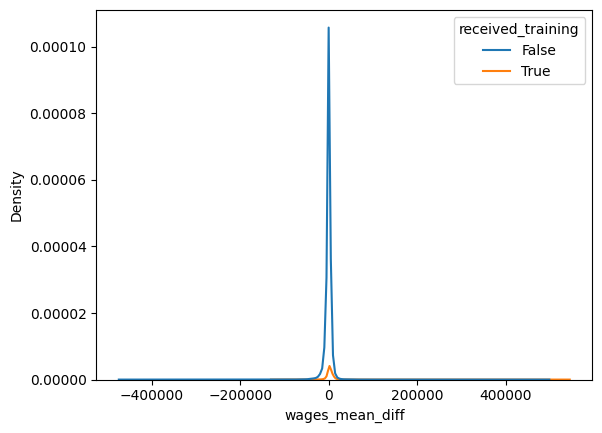

In [155]:
ax = sns.kdeplot(df_complete, x="wages_mean_diff", hue="received_training")

# ax.set_xlim(p10, p90)



In [151]:
df_complete

unique_id,sex,race,age,highest_educational_level,low_income_status,employment_status,state,is_adult,is_dislocated_worker,is_youth,is_wagner_peyser,is_reportable_individual,received_training,entry_date,exit_date,entry_year,entry_quarter,exit_year,exit_quarter,inflation_ratio_exit,inflation_ratio_entry,industry_code_pre,industry_code_post,subsector_code_pre,subsector_code_post,workforce_board_code,funding_stream,wages_mean_diff,workforce_board_population_per_sqkm,workforce_board_median_age,workforce_board_median_income,diff_r_cog_subsector,diff_r_man_subsector,diff_offshor_subsector
str,i64,i64,i64,i64,i64,i64,str,bool,bool,bool,bool,bool,bool,date,date,i32,i8,i32,i8,f64,f64,str,str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64
"""549c44SeF45U""",1,6,53,2,0,0,"""WV""",false,false,false,true,false,false,2017-05-23,2017-05-23,2017,2,2017,2,0.889589,0.889589,"""561320""","""561320""","""561000""","""561000""","""54045""","""Wagner-Peyser""",1549,46.798953,45.8375,34554.125,0.0,0.0,0.0
"""SAcUc4e5adF0""",2,6,43,2,0,1,"""TX""",false,false,false,true,false,false,2018-04-03,2018-04-03,2018,2,2018,2,0.868379,0.868379,"""311611""","""424940""","""311000""","""424000""","""48165""","""Wagner-Peyser""",788,32.863514,40.133333,36906.666667,-0.303123,-1.08016,0.368872
"""S049c00Fbb4S""",2,1,43,1,0,0,"""UT""",false,false,false,true,false,false,2024-05-07,2024-05-07,2024,2,2024,2,0.695134,0.695134,"""459999""","""722513""","""459000""","""722000""","""49050""","""Wagner-Peyser""",-6629,53.5491,35.834483,35625.034483,-0.309266,0.474208,0.252334
"""9Fdb0LffLFdd""",2,1,50,2,1,1,"""NM""",false,false,false,true,false,false,2023-08-15,2023-08-15,2023,3,2023,3,0.715637,0.715637,"""621610""","""621610""","""621000""","""621000""","""35030""","""Wagner-Peyser""",194,4.563581,45.928571,25808.571429,0.0,0.0,0.0
"""USUdAaSFeaee""",1,5,34,4,0,0,"""NV""",false,false,false,true,false,false,2022-02-07,2022-02-07,2022,1,2022,1,0.745096,0.745096,"""999999""","""999999""","""999000""","""999000""","""32005""","""Wagner-Peyser""",-11506,29.69748,47.525,33458.5,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""4a9LSbff95be""",2,1,29,1,1,0,"""TX""",false,false,false,true,false,false,2022-02-07,2022-03-21,2022,1,2022,1,0.745096,0.745096,"""455110""","""561422""","""455000""","""561000""","""48265""","""Wagner-Peyser""",4778,86.316945,31.033333,22780.666667,-0.032909,0.124525,0.379998
"""Ue9DbfALDA4D""",1,6,65,7,0,0,"""CO""",false,false,false,true,false,false,2022-09-14,2022-09-14,2022,3,2022,3,0.745096,0.745096,"""623110""","""561320""","""623000""","""561000""","""8060""","""Wagner-Peyser""",415,76.956792,43.5,42791.0,0.512915,0.441148,0.176155
"""4F9bcd4b0a0F""",2,6,27,1,0,0,"""KY""",false,false,false,true,false,false,2022-10-14,2022-10-14,2022,4,2022,4,0.745096,0.745096,"""722513""","""457110""","""722000""","""457000""","""21010""","""Wagner-Peyser""",1401,34.348129,40.42,29490.3,0.997141,0.381539,0.083967


In [16]:
urban_threshold_per_sqmi = 100
urban_threshold_per_sqkm = urban_threshold_per_sqmi * (1/2.59)

In [17]:
urban_threshold_per_sqkm

38.61003861003861

In [7]:
df_index = df_index.to_pandas()

In [8]:
df_index

,unique_id,sex,race,age,highest_educational_level,low_income_status,employment_status,occupational_code_pre,industry_code_q1_pre,industry_code_q2_pre,...,offshor_industry_post,population_per_sqkm,median_age,median_income,diff_r_cog,diff_r_man,diff_offshor,diff_r_cog_industry,diff_r_man_industry,diff_offshor_industry
0,549c44SeF45U,1,6,53,2,0,0,None,561320,None,...,-0.066362,46.798953,45.837500,34554.125000,NaN,NaN,NaN,0.0,0.0,0.0
1,SAcUc4e5adF0,2,6,43,2,0,1,None,None,None,...,NaN,32.863514,40.133333,36906.666667,NaN,NaN,NaN,NaN,NaN,NaN
2,S049c00Fbb4S,2,1,43,1,0,0,None,459999,459999,...,NaN,53.549100,35.834483,35625.034483,NaN,NaN,NaN,NaN,NaN,NaN
3,9Fdb0LffLFdd,2,1,50,2,1,1,None,621610,None,...,NaN,4.563581,45.928571,25808.571429,NaN,NaN,NaN,NaN,NaN,NaN
4,USUdAaSFeaee,1,5,34,4,0,0,537065,None,999999,...,NaN,29.697480,47.525000,33458.500000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188082,Ue9DbfALDA4D,1,6,65,7,0,0,None,623110,623110,...,-0.066362,76.956792,43.500000,42791.000000,NaN,NaN,NaN,NaN,NaN,NaN
188083,caaSad0bFe99,1,1,47,0,0,0,373011,110000,561720,...,-0.660815,28.457456,41.683333,29307.166667,NaN,NaN,NaN,NaN,NaN,NaN
188084,4F9bcd4b0a0F,2,6,27,1,0,0,None,None,722513,...,NaN,34.348129,40.420000,29490.300000,NaN,NaN,NaN,NaN,NaN,NaN
188085,efa5c440599F,1,6,50,5,1,0,None,332322,332322,...,-0.066362,1362.130420,48.900000,38779.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
lf_performance_records = pl.scan_parquet("../data/processed/performance_records/performance_records.parquet")

In [3]:
(
    lf_performance_records.filter(
        pl.col("occupational_code_pre").is_not_null() &
        pl.col("occupational_code_post").is_not_null(),
        cs.starts_with("wages").is_not_null()
    )
    .group_by(
        pl.col("funding_stream")
    )
    .agg(
        pl.len()
    )
    .collect()
)

funding_stream,len
str,u32
"""Adult""",108169
"""Youth""",8215
"""Adult, Dislocated worker, or Y…",8020
"""Dislocated Worker""",80782
"""Wagner-Peyser""",116287


In [9]:
(
    lf_performance_records.filter(
        pl.col("occupational_code_pre").is_not_null() &
        pl.col("occupational_code_post").is_not_null(),
    )
    .select(pl.len())
    .collect()
)

len
u32
571470


In [49]:
df_performance_records["wages_mean_diff"] = df_performance_records["wages_mean_post"] - df_performance_records["wages_mean_pre"]
df_performance_records["wages_mean_diff_zscore"] = stats.zscore(df_performance_records["wages_mean_diff"])

mu = df_performance_records["wages_mean_diff"].mean()
sigma = df_performance_records["wages_mean_diff"].std(ddof=0)

In [55]:
is_occupational_code_pre_na = df_performance_records.occupational_code_pre.isna()
is_occupational_code_post_na = df_performance_records.occupational_code_pre.isna()

df_performance_records[~(is_occupational_code_pre_na & is_occupational_code_post_na)].groupby(by=["funding_stream"])[["wages_mean_diff"]].count()

,wages_mean_diff
funding_stream,
Adult,658590
"Adult, Dislocated worker, or Youth",54513
Dislocated Worker,882900
Wagner-Peyser,8217158
Youth,35244


In [ ]:
133224

In [67]:
df_performance_records["occupational_code_post"].isna().sum() / df_performance_records["wages_3q_post"].count()

np.float64(1.302038803759527)

In [56]:
df_performance_records[~(is_occupational_code_pre_na & is_occupational_code_post_na)].sample(5)

,unique_id,sex,race,age,highest_educational_level,low_income_status,employment_status,occupational_code_pre,industry_code_q1_pre,industry_code_q2_pre,...,industry_code_pre,industry_code_post,subsector_code_pre,subsector_code_post,workforce_board_code,funding_stream,wages_mean_post,wages_mean_pre,wages_mean_diff,wages_mean_diff_zscore
12671215,4fA9bDUAd0D4,2,3,49,1,0,1,537064,999999,999999,...,999999,999999,999000,999000,13110,Wagner-Peyser,6668,6800,-132,0.084702
9282701,S5Lce94Ffaac,2,6,35,5,0,0,433031,238220,238220,...,238220,453900,238000,453000,13270,Wagner-Peyser,447,5654,-5207,-0.419555
15233242,UDadDSUfAFeF,1,3,38,4,0,0,530000,325620,325620,...,325620,561320,325000,561000,48255,Wagner-Peyser,7091,6422,669,0.164290
4376202,aLFL5dA00a9A,1,1,34,1,0,1,151299,999999,999999,...,999999,999999,999000,999000,6175,Adult,6205,10189,-3984,-0.298037
14093341,5bU5df4D5c5b,1,6,58,8,0,0,119021,236220,236220,...,236220,238350,236000,238000,36015,Dislocated Worker,18601,26354,-7753,-0.672529


In [ ]:
df_performance_records.groupby(by=["funding_stream"])[["wages_mean_diff"]].count()

,wages_mean_diff
funding_stream,
Adult,1914038
"Adult, Dislocated worker, or Youth",483368
Dislocated Worker,1270909
Wagner-Peyser,19327143
Youth,137180


In [57]:
df_performance_records.groupby(by=["race"])[["wages_mean_diff"]].mean().apply(lambda x: (x - mu) / sigma)

,wages_mean_diff
race,
1,0.061107
2,-0.166794
3,0.065395
4,0.013543
5,0.039796
6,-0.059602
7,0.024483


In [68]:
wages_upper = df_performance_records["wages_mean_diff"].quantile(0.95)
wages_lower = df_performance_records["wages_mean_diff"].quantile(0.05)
median = df_performance_records["wages_mean_diff"].quantile(0.5)

is_between = (df_performance_records["wages_mean_diff"] > wages_lower) & (df_performance_records["wages_mean_diff"] < wages_upper)

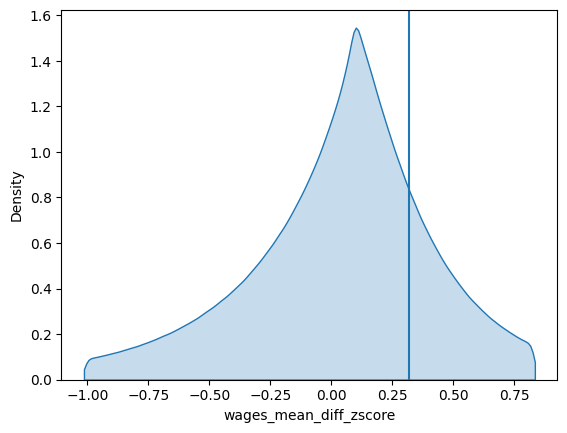

In [69]:
ax = sns.kdeplot(data=df_performance_records[is_between], x="wages_mean_diff_zscore", cut=0, fill=True)
ax.axvline(x=0.317453)


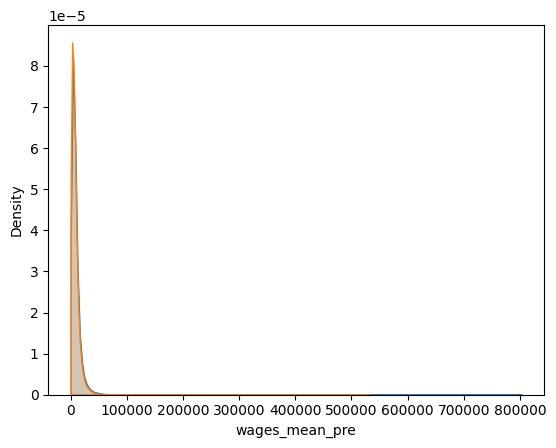

In [9]:
ax = sns.kdeplot(data=df_performance_records, x="wages_mean_pre", cut=0, fill=True)
ax = sns.kdeplot(data=df_performance_records, x="wages_mean_post", cut=0, fill=True, ax=ax)


## Routine Task Intensity


In [42]:
df_rti_industries = pd.read_parquet("../data/processed/routine_task_intensity/routine_task_intensity_industry.parquet")
df_rti_subsector = pd.read_parquet("../data/processed/routine_task_intensity/routine_task_intensity_subsector.parquet")


<Axes: xlabel='r_cog_industry', ylabel='Density'>

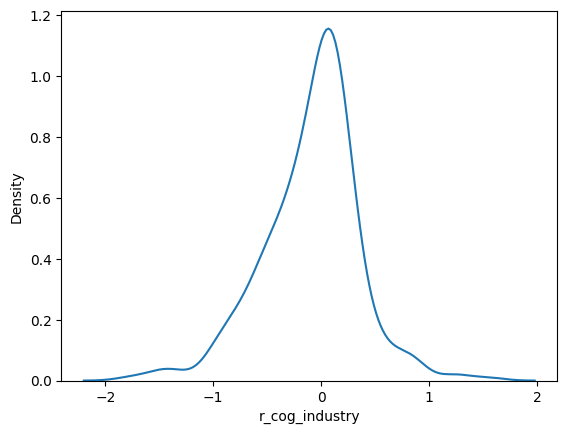

In [43]:
sns.kdeplot(df_rti_industries["r_cog_industry"])

<Axes: xlabel='r_man_subsector', ylabel='Count'>

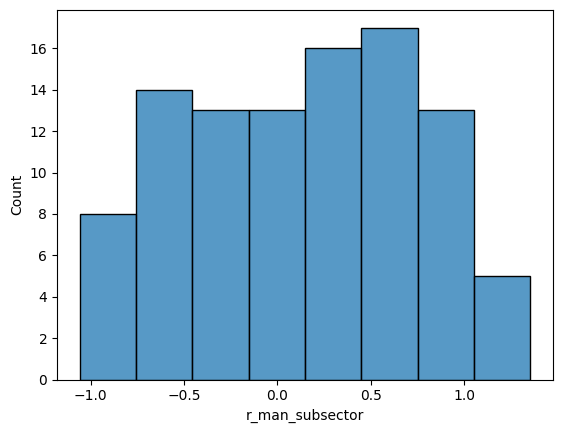

In [48]:
sns.histplot(df_rti_subsector["r_man_subsector"])

In [38]:
df_rti_industries.sample(5)

,industry_code,sector_code,subsector_code,industry_group_code,naics_industry_code,industry_title,sector_title,subsector_title,r_cog_industry,r_man_industry,offshor_industry
289,62220L,620000,622000,622200,622200,Psychiatric and substance abuse hospitals; local,Healthcare and social assistance,"Hospitals; state, local, and private",0.050723,-1.044120,-0.247589
126,313000,310000,313000,313000,313000,Textile mills,Manufacturing,Textile mills and textile product mills,0.125822,0.687289,-0.028600
8,62220P,620000,622000,622200,622200,Psychiatric and substance abuse hospitals; pri...,Healthcare and social assistance,"Hospitals; state, local, and private",-0.055448,-0.785193,-0.107240
120,487200,480000,487000,487200,487200,"Scenic and sightseeing transportation, water",Transportation and warehousing,Scenic and sightseeing transportation,0.031054,0.224019,-0.278330
162,621600,620000,621000,621600,621600,Home healthcare services,Healthcare and social assistance,Ambulatory healthcare services,-0.087632,-0.590240,-0.534013


## Industries


In [18]:
df_industries = pd.read_parquet("../data/processed/industries/industries.parquet")
df_occupations = pd.read_parquet("../data/processed/occupations/occupations.parquet")

In [19]:
df_industries[["industry_code", "sector_code", "subsector_code", "industry_group_code", "naics_industry_code"]].nunique()

industry_code          292
sector_code             25
subsector_code          90
industry_group_code    241
naics_industry_code    263
dtype: int64

In [20]:
df_industry_occupations = df_industries.merge(df_occupations, on="occupation_code", how="left")

In [26]:
df_industries.columns

Index(['occupation_type', 'industry_type', 'industry_code', 'sector_code',
       'subsector_code', 'industry_group_code', 'naics_industry_code',
       'industry_title', 'occupation_code', '2023_percent_of_industry',
       '2033_percent_of_industry', 'sector_title', 'subsector_title'],
      dtype='object')

In [22]:
df_industry_occupations.sample(5)

,occupation_type,industry_type,industry_code,sector_code,subsector_code,industry_group_code,naics_industry_code,industry_title,occupation_code,2023_percent_of_industry,2033_percent_of_industry,sector_title,subsector_title,occupation_title,occupation_level,occupation_code_prefix
15711,Line item,Line item,482000,480000,482000,482000,482000,Rail transportation,534099,0.1,0.1,Transportation and warehousing,Rail transportation,"Rail Transportation Workers, All Other",detailed_occupation,53
8415,Line item,Line item,332720,330000,332000,332700,332720,"Turned product and screw, nut, and bolt manufa...",537062,2.1,2.2,Manufacturing,Fabricated metal product manufacturing,"Laborers and Freight, Stock, and Material Move...",detailed_occupation,53
754,Line item,Line item,111000,110000,111000,111000,111000,Crop production,537051,0.9,0.9,"Agriculture, forestry, fishing and hunting",Crop production,Industrial Truck and Tractor Operators,detailed_occupation,53
26779,Line item,Line item,61120S,610000,611000,611200,611200,Junior colleges; state,151241,0.0,0.0,"Educational services; state, local, and private","Educational services; state, local, and private",Computer Network Architects,detailed_occupation,15
31754,Line item,Line item,624300,620000,624000,624300,624300,Vocational rehabilitation services,319092,0.0,0.0,Healthcare and social assistance,Social assistance,Medical Assistants,detailed_occupation,31


In [24]:
temp_df = df_industry_occupations[df_industry_occupations.sector_code == "510000"][["sector_title", "industry_title", "occupation_title", "2023_percent_of_industry"]].sort_values(by="2023_percent_of_industry", ascending=False)
temp_df[temp_df["2023_percent_of_industry"] > 1]

,sector_title,industry_title,occupation_title,2023_percent_of_industry
17989,Information,Motion picture and video exhibition,"Ushers, Lobby Attendants, and Ticket Takers",47.5
18303,Information,Radio broadcasting stations,Broadcast Announcers and Radio Disc Jockeys,27.2
18097,Information,Software publishers,Software Developers,25.3
18563,Information,"Web search portals, libraries, archives, and o...",Software Developers,24.3
18373,Information,Television broadcasting stations,Producers and Directors,21.1
...,...,...,...,...
18544,Information,"Web search portals, libraries, archives, and o...",Management Analysts,1.1
18008,Information,Sound recording industries,Financial Managers,1.1
18564,Information,"Web search portals, libraries, archives, and o...",Software Quality Assurance Analysts and Testers,1.1
18477,Information,"Media streaming distribution services, social ...",Public Relations Specialists,1.1


In [10]:
len(df_industry_occupations) / len(df_industries)

1.0

<Axes: xlabel='2023_percent_of_industry', ylabel='Count'>

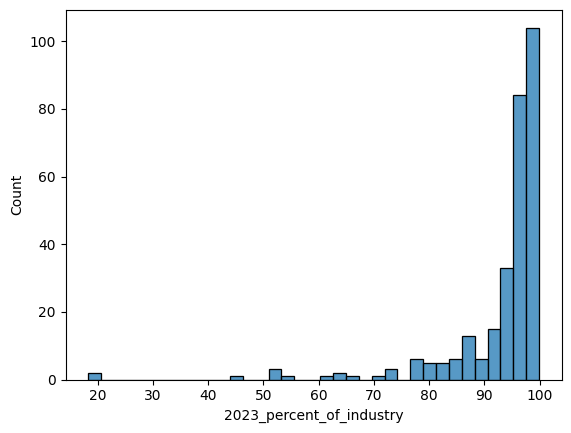

In [44]:
sns.histplot(df_industry_occupations.groupby("industry_code")["2023_percent_of_industry"].sum().sort_values())

In [49]:
df_industry_occupations["occupation_level"].value_counts(normalize=True)

occupation_level
detailed_occupation    0.983844
broad_group            0.016156
Name: proportion, dtype: float64

,occupation_type,industry_type,industry_code,sector_code,subsector_code,industry_group_code,naics_industry_code,industry_title,occupation_code,2023_percent_of_industry,2033_percent_of_industry,occupation_title,occupation_level,occupation_code_prefix
26349,Line item,Line item,61150L,610000,611000,611500,611500,Technical and trade schools; local,253031,2.6,2.6,"Substitute Teachers, Short-Term",detailed_occupation,25
29256,Line item,Line item,623100,620000,623000,623100,623100,Nursing care facilities (skilled nursing facil...,433031,0.4,0.3,"Bookkeeping, Accounting, and Auditing Clerks",detailed_occupation,43
16465,Line item,Line item,488900,480000,488000,488900,488900,Other support activities for transportation,436014,0.7,0.7,"Secretaries and Administrative Assistants, Exc...",detailed_occupation,43
30184,Line item,Line item,624300,620000,624000,624300,624300,Vocational rehabilitation services,273091,0.0,0.0,Interpreters and Translators,detailed_occupation,27
31207,Line item,Line item,713200,710000,713000,713200,713200,Gambling industries (except casino hotels),112021,0.4,0.4,Marketing Managers,detailed_occupation,11


,industry_title,occupation_title,2023_percent_of_industry
26343,Technical and trade schools; local,"Career/Technical Education Teachers, Postsecon...",28.0
26360,Technical and trade schools; local,"Secretaries and Administrative Assistants, Exc...",5.4
26346,Technical and trade schools; local,"Career/Technical Education Teachers, Secondary...",5.2
26354,Technical and trade schools; local,"Janitors and Cleaners, Except Maids and Housek...",3.8
26347,Technical and trade schools; local,"Adult Basic Education, Adult Secondary Educati...",3.7
26339,Technical and trade schools; local,"Educational, Guidance, and Career Counselors a...",3.4
26350,Technical and trade schools; local,Instructional Coordinators,3.2
26335,Technical and trade schools; local,"Education Administrators, Postsecondary",2.9
26349,Technical and trade schools; local,"Substitute Teachers, Short-Term",2.6
26341,Technical and trade schools; local,"Health Specialties Teachers, Postsecondary",2.6


# Playground


In [2]:
DATA_FOLDER = "../data/processed"
lf = pl.scan_parquet(f"{DATA_FOLDER}/index_data.parquet")

In [3]:
lf.collect_schema().names()

['unique_id',
 'sex',
 'race',
 'age',
 'highest_educational_level',
 'low_income_status',
 'employment_status',
 'occupational_code_pre',
 'industry_code_q1_pre',
 'industry_code_q2_pre',
 'industry_code_q3_pre',
 'wages_3q_pre',
 'wages_2q_pre',
 'wages_1q_pre',
 'occupational_code_post',
 'industry_code_q1_post',
 'industry_code_q2_post',
 'industry_code_q3_post',
 'industry_code_q4_post',
 'wages_1q_post',
 'wages_2q_post',
 'wages_3q_post',
 'wages_4q_post',
 'workforce_board_code_1',
 'workforce_board_code_2',
 'workforce_board_code_3',
 'state',
 'is_adult',
 'is_dislocated_worker',
 'is_youth',
 'is_wagner_peyser',
 'is_reportable_individual',
 'received_training',
 'entry_date',
 'exit_date',
 'entry_year',
 'entry_quarter',
 'exit_year',
 'exit_quarter',
 'industry_code_pre',
 'industry_code_post',
 'funding_stream',
 'subsector_code_pre',
 'subsector_code_post',
 '',
 'occupation_title_pre',
 'r_cog_pre',
 'r_man_pre',
 'offshor_pre',
 '_right',
 'occupation_title_post',
 'r

In [4]:
n_rows = lf.select(pl.len()).collect().item()
print("Number of rows: ", n_rows)

Number of rows:  12726789


In [5]:
df = lf.collect()

In [6]:
df_sample = df.sample(fraction=0.01, with_replacement=False)
n_rows_sample = df_sample.select(pl.len()).item()
print("Number of rows in sample: ", n_rows_sample)

Number of rows in sample:  127267


In [7]:
df_sample = df_sample.to_pandas()

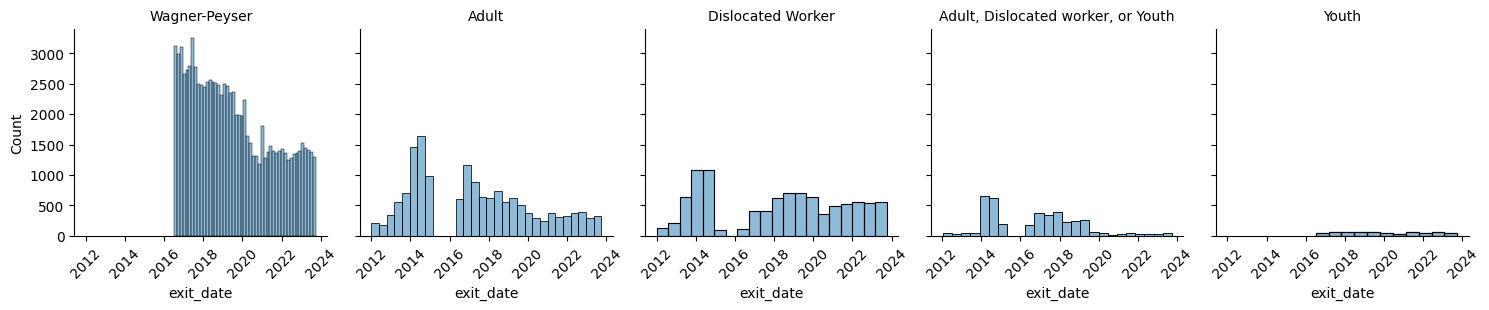

In [8]:
g = sns.FacetGrid(df_sample, col="funding_stream", despine=True)

g.map_dataframe(sns.histplot, x="exit_date", hue="funding_stream")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

g.figure.show()

In [35]:
import matplotlib.pyplot as plt

In [45]:
df_sample.columns

Index(['unique_id', 'sex', 'race', 'age', 'highest_educational_level',
       'low_income_status', 'employment_status', 'occupational_code_pre',
       'industry_code_q1_pre', 'industry_code_q2_pre', 'industry_code_q3_pre',
       'wages_3q_pre', 'wages_2q_pre', 'wages_1q_pre',
       'occupational_code_post', 'industry_code_q1_post',
       'industry_code_q2_post', 'industry_code_q3_post',
       'industry_code_q4_post', 'wages_1q_post', 'wages_2q_post',
       'wages_3q_post', 'wages_4q_post', 'workforce_board_code_1',
       'workforce_board_code_2', 'workforce_board_code_3', 'state', 'is_adult',
       'is_dislocated_worker', 'is_youth', 'is_wagner_peyser',
       'is_reportable_individual', 'received_training', 'entry_date',
       'exit_date', 'entry_year', 'entry_quarter', 'exit_year', 'exit_quarter',
       'industry_code_pre', 'industry_code_post', 'funding_stream',
       'subsector_code_pre', 'subsector_code_post', '', 'occupation_title_pre',
       'r_cog_pre', 'r_man_pre',

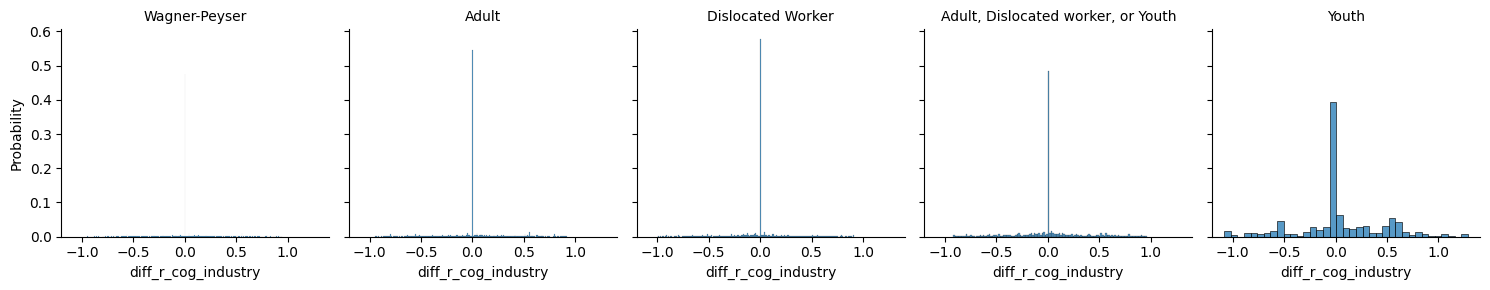

In [73]:
metric = "diff_r_cog_industry"

q_low = df_sample.groupby("funding_stream")[metric].transform(lambda x: x.quantile(0.01))
q_high = df_sample.groupby("funding_stream")[metric].transform(lambda x: x.quantile(0.99))

df_filtered = df_sample[(df_sample[metric] >= q_low) & (df_sample[metric] <= q_high)]

g = sns.FacetGrid(df_filtered, col="funding_stream", despine=True)

g.map_dataframe(sns.histplot, x=metric, stat="probability")

# for ax in g.axes.flatten():
#     ax.set_xlim(-100000, 100000)

g.set_titles(col_template="{col_name}")

g.figure.show()